# Week 6 - Bivariate Analysis, part 2

# 1. Lesson: no lesson this week

# 2. Weekly graph question

Suppose you wanted to show the nitrate and phosphate level in a water sample.  What are the advantages and disadvantages of showing this as an area plot, as opposed to two separate line graphs?  How would you adjust the graphs shown to improve the presentation?

In [1]:
import numpy as np
import seaborn as sns
import pandas as pd

/tmp/ipykernel_40457/2149468501.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')


Text(0, 0.5, 'Nitrate level (% of eutrophic value)')

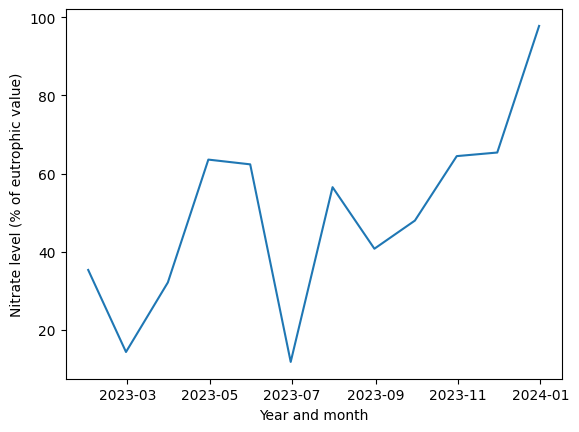

In [2]:
numdates = 12
np.random.seed(0)
time_series = 100 * (np.random.normal(size = numdates) / 5 + np.arange(numdates) / 16)
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Nitrate level (% of eutrophic value)")

/tmp/ipykernel_40457/1726504607.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')


Text(0, 0.5, 'Phosphate level (% of eutrophic value)')

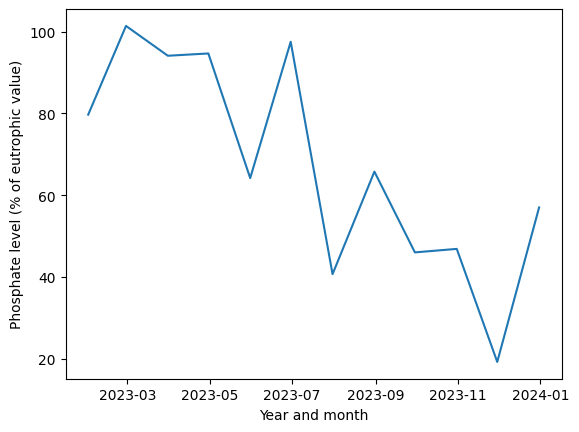

In [3]:
np.random.seed(1)
time_series_2 =  100 * (1 - (np.random.normal(size = numdates) / 8 + np.arange(numdates) / 16))
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series_2)
ax.set_xlabel("Year and month")
ax.set_ylabel("Phosphate level (% of eutrophic value)")

<Axes: >

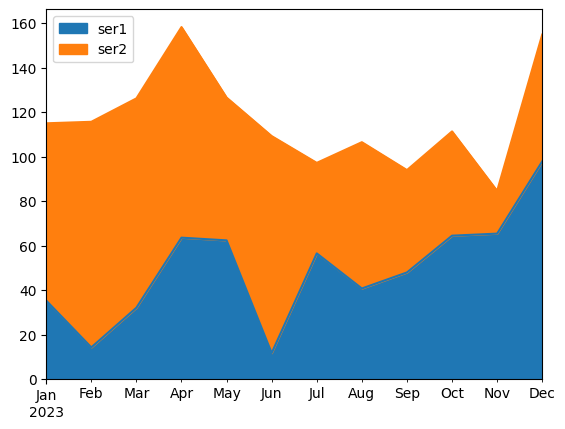

In [4]:
df = pd.DataFrame({'ser1': time_series, 'ser2': time_series_2}, index = datearray)
df.plot.area()

Line graphs have the advantages of showing trends for each separate graph as well as reducing the room for confusion if there's a lot of fluctuation between the datasets.

The area plot is more concise and allows for interpretation of trends between the two datasets. The downside is there could be a precieved correlation even if there is no correlation between the two variables being displayed.

To improve the area plot, I would make it more transparent so both variables remain visible.

TO improve the line graphs, I would use different colors for each scenario to help differentiate between the two graphs more easily.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Find correlations between pairs of variables.

- Draw scatterplots, especially when the correlation is large.

- Draw pairplots.

- Draw line graphs and/or area graphs when there is date or time data together with numerical data.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If the data are not useable, find some new data!

- Do you see any outliers?  (Data points that are far from the rest of the data).

- Are any data items highly correlated with each other, suggesting that they are redundant?

- For the line plots, do you see a trend or pattern over time?  Does this suggest that the data are changing over time (drifting) in such a way as to invalidate comparisons?

- Can you think of any confounding variables?  (Third variables that could explain any correlations between other variables.  These third variables may or may not be reported in the dataset.)

In [5]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "austinHousingData.csv"


df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "ericpierce/austinhousingprices",
  file_path,
  # Provide any additional arguments like 
    pandas_kwargs={"sep": ","}
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())


/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_40457/3122336420.py:7: DeprecationWarning: load_dataset is deprecated and will be removed in future version.
  df = kagglehub.load_dataset(


First 5 records:          zpid          city          streetAddress  zipcode  \
0   111373431  pflugerville   14424 Lake Victor Dr    78660   
1   120900430  pflugerville     1104 Strickling Dr    78660   
2  2084491383  pflugerville    1408 Fort Dessau Rd    78660   
3   120901374  pflugerville     1025 Strickling Dr    78660   
4    60134862  pflugerville  15005 Donna Jane Loop    78660   

                                         description   latitude  longitude  \
0  14424 Lake Victor Dr, Pflugerville, TX 78660 i...  30.430632 -97.663078   
1  Absolutely GORGEOUS 4 Bedroom home with 2 full...  30.432673 -97.661697   
2  Under construction - estimated completion in A...  30.409748 -97.639771   
3  Absolutely darling one story home in charming ...  30.432112 -97.661659   
4  Brimming with appeal & warm livability! Sleek ...  30.437368 -97.656860   

   propertyTaxRate  garageSpaces  hasAssociation  ...  numOfMiddleSchools  \
0             1.98             2            True  ...     

In [6]:
print(df.columns)

Index(['zpid', 'city', 'streetAddress', 'zipcode', 'description', 'latitude',
       'longitude', 'propertyTaxRate', 'garageSpaces', 'hasAssociation',
       'hasCooling', 'hasGarage', 'hasHeating', 'hasSpa', 'hasView',
       'homeType', 'parkingSpaces', 'yearBuilt', 'latestPrice',
       'numPriceChanges', 'latest_saledate', 'latest_salemonth',
       'latest_saleyear', 'latestPriceSource', 'numOfPhotos',
       'numOfAccessibilityFeatures', 'numOfAppliances', 'numOfParkingFeatures',
       'numOfPatioAndPorchFeatures', 'numOfSecurityFeatures',
       'numOfWaterfrontFeatures', 'numOfWindowFeatures',
       'numOfCommunityFeatures', 'lotSizeSqFt', 'livingAreaSqFt',
       'numOfPrimarySchools', 'numOfElementarySchools', 'numOfMiddleSchools',
       'numOfHighSchools', 'avgSchoolDistance', 'avgSchoolRating',
       'avgSchoolSize', 'MedianStudentsPerTeacher', 'numOfBathrooms',
       'numOfBedrooms', 'numOfStories', 'homeImage'],
      dtype='object')


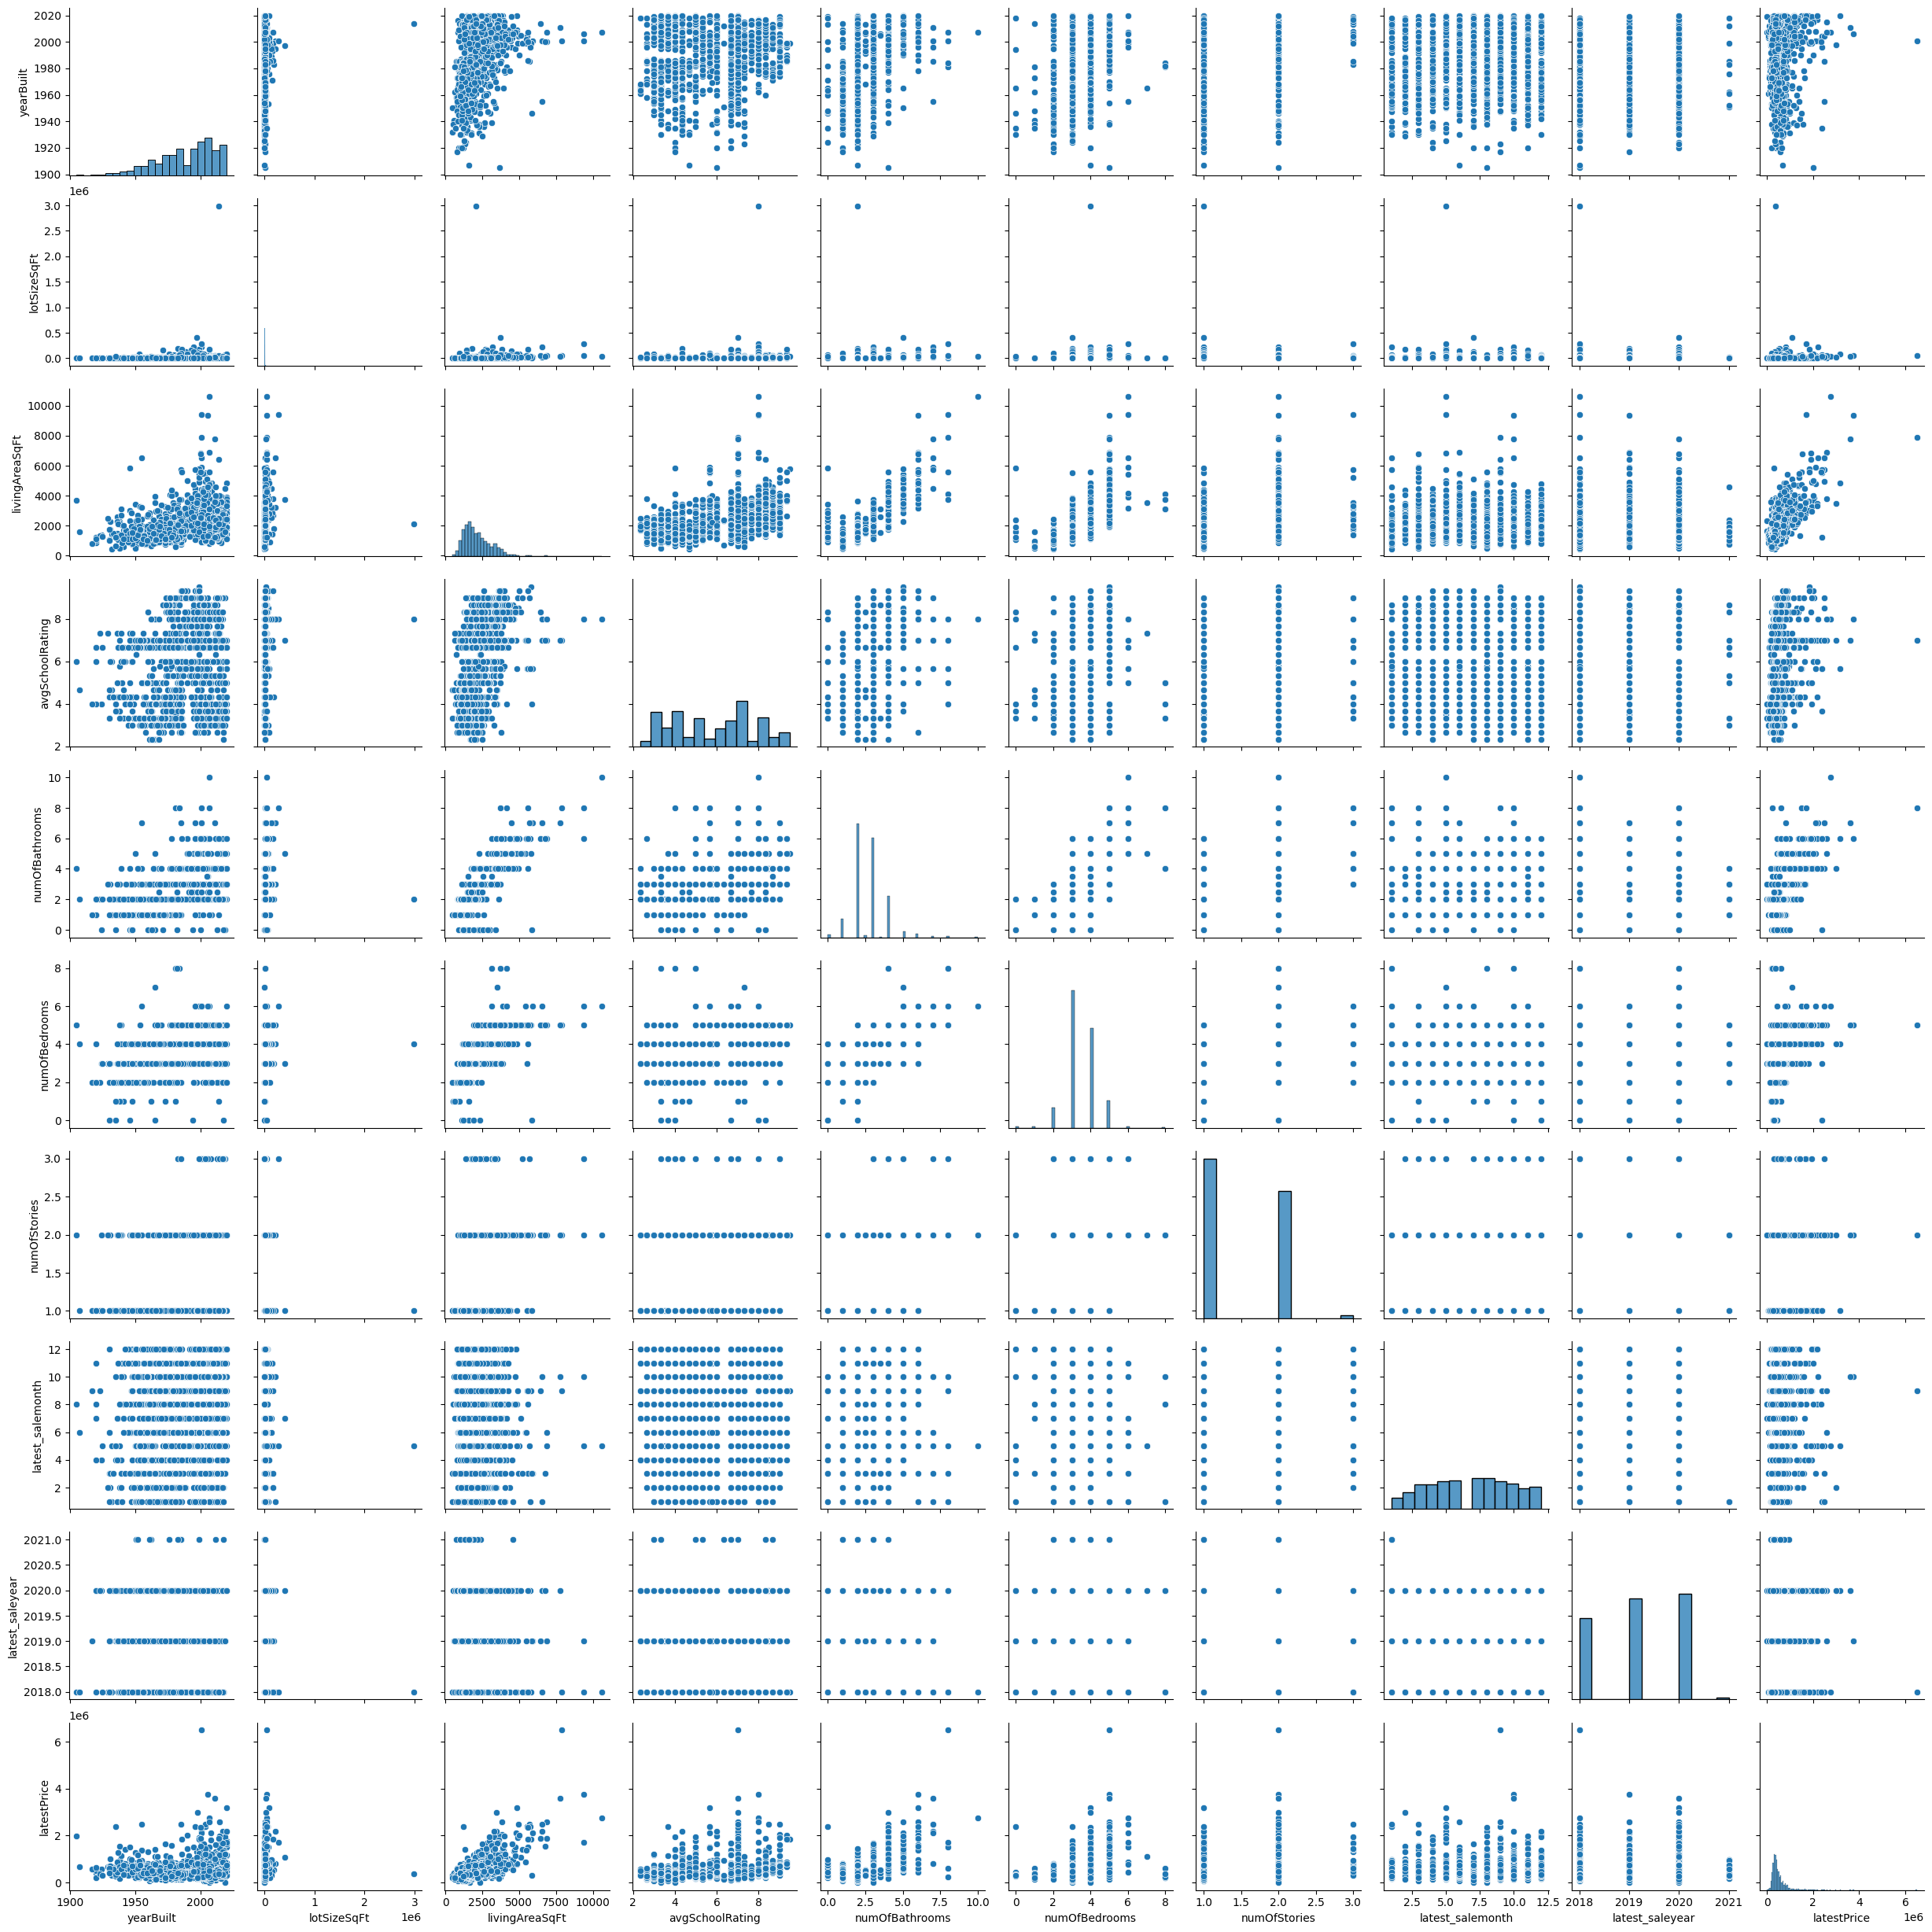

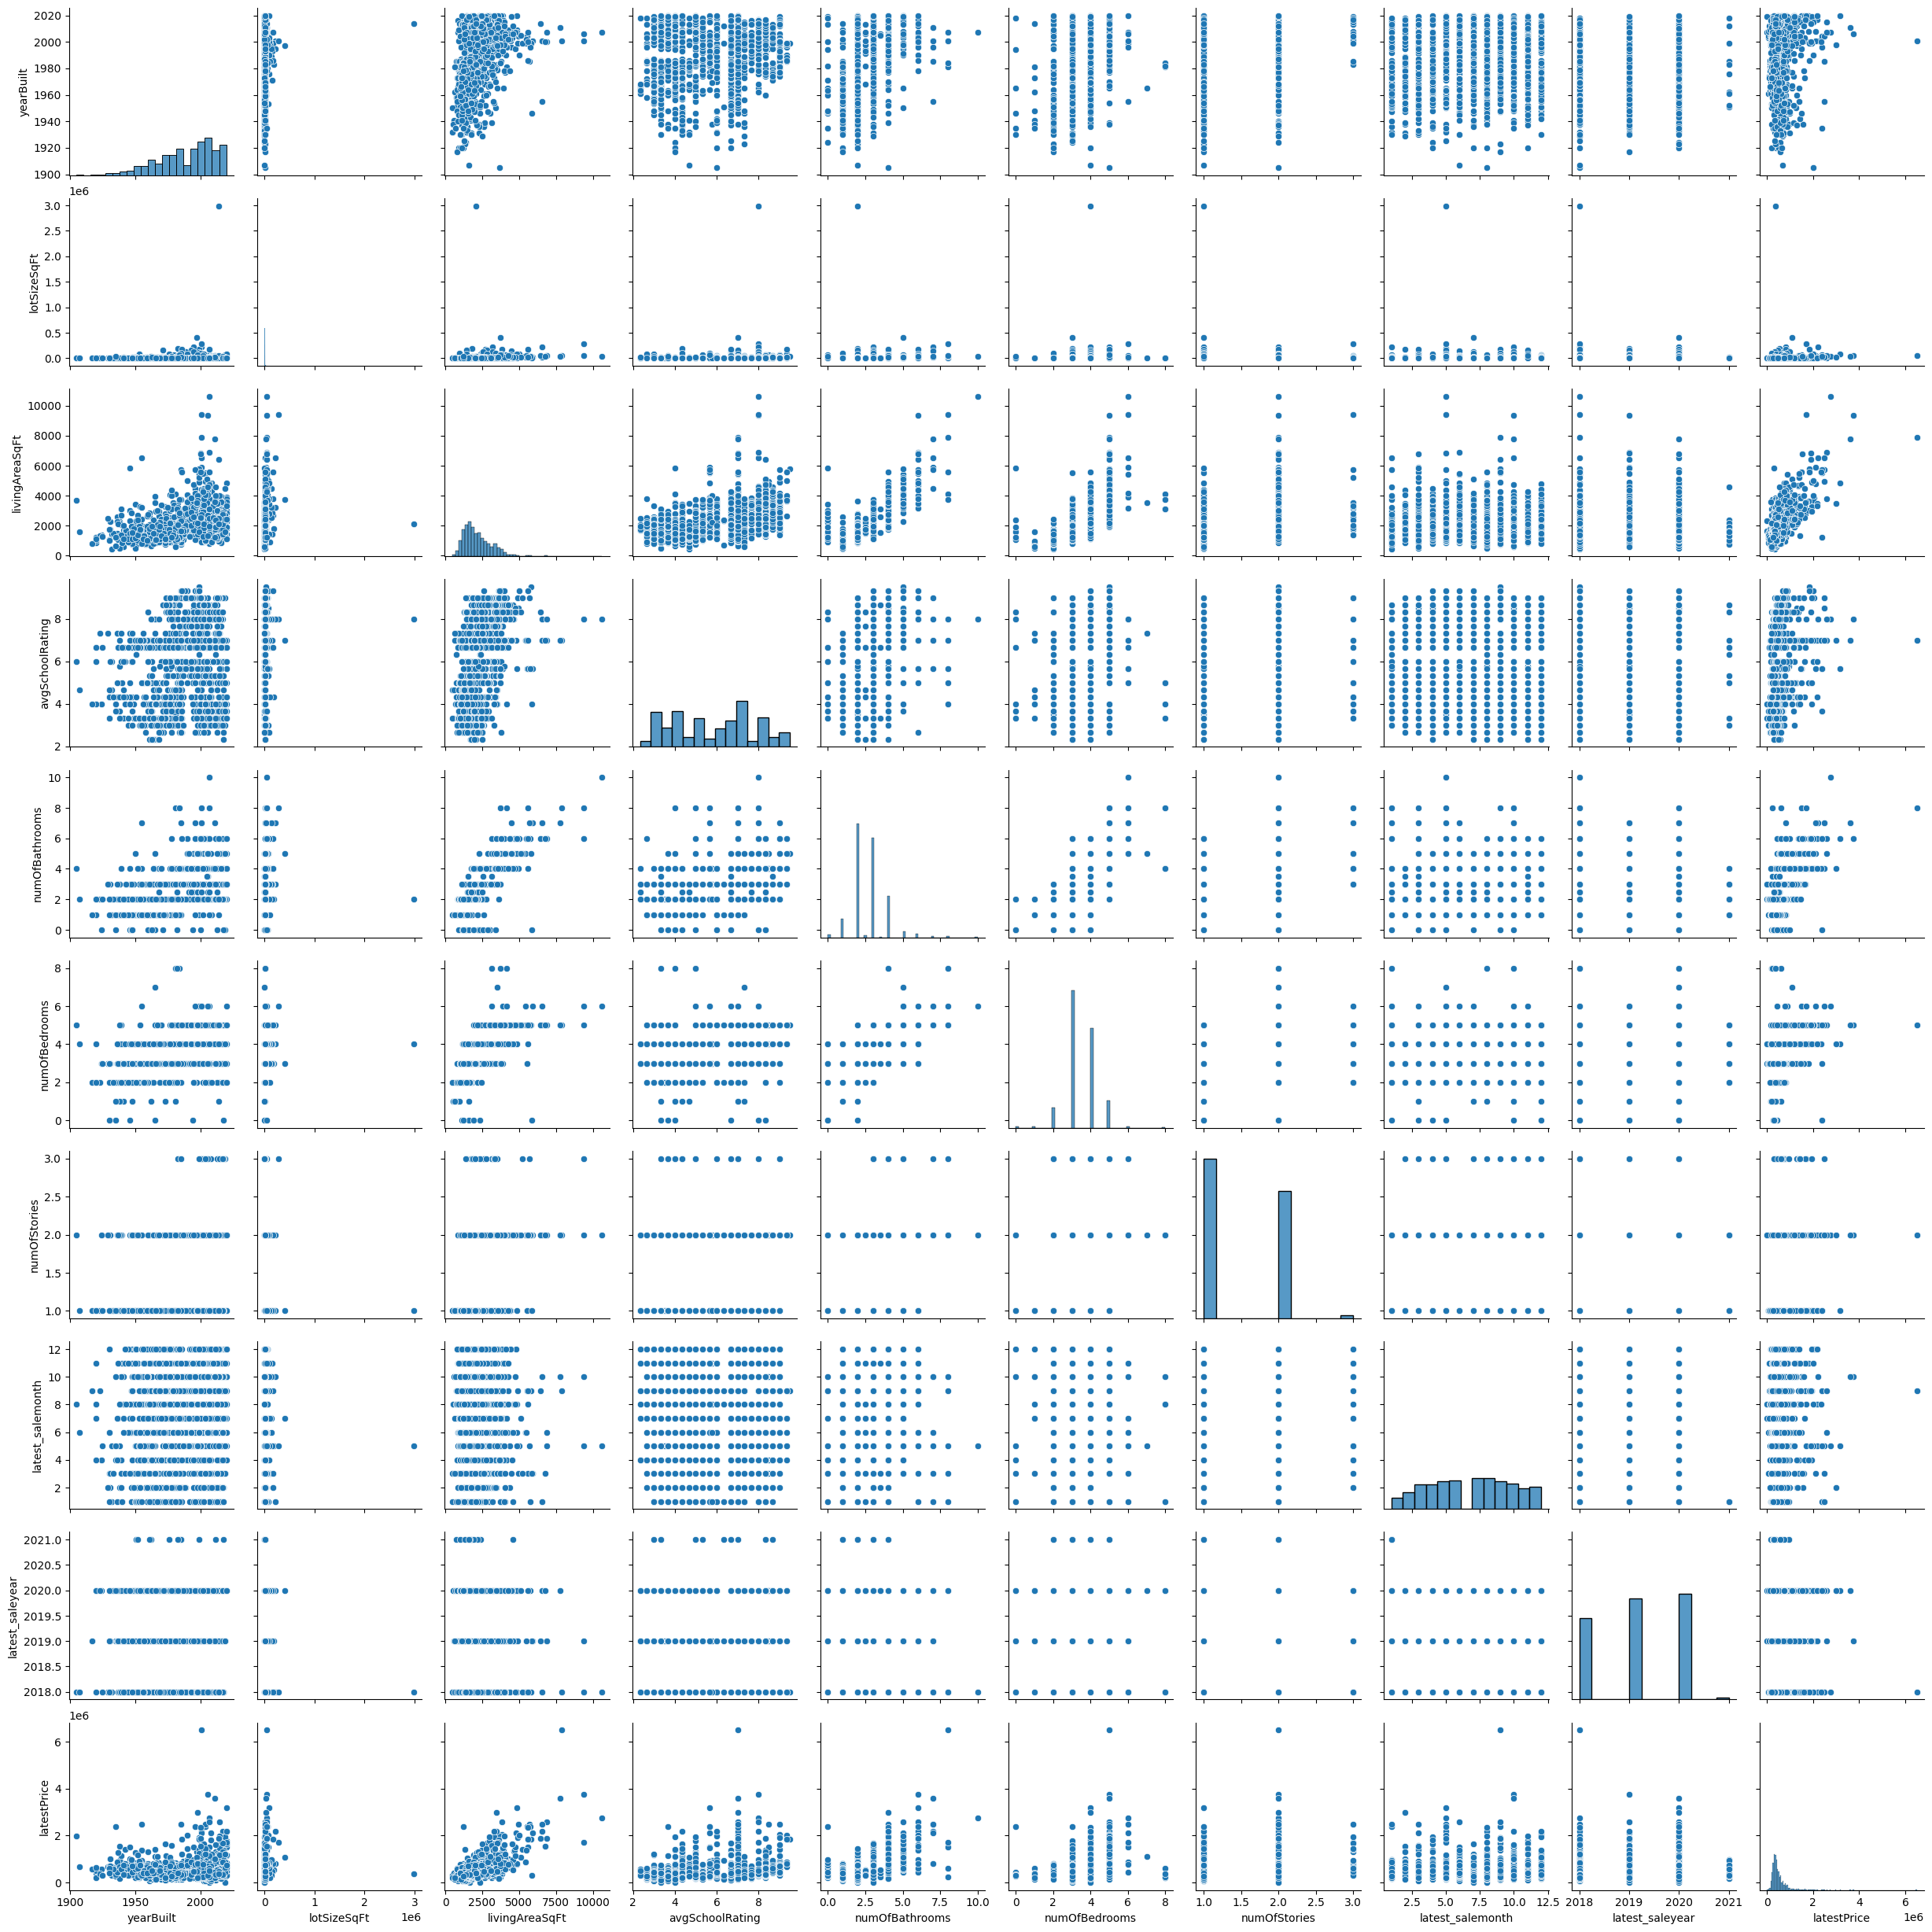

In [8]:
usable_columns = df.select_dtypes(include=['int64', 'float64'])
usable_columns = usable_columns.drop(columns=['zpid','zipcode','latitude','longitude'])

pairplot_columns = usable_columns[['yearBuilt', 'lotSizeSqFt', 'livingAreaSqFt', 'avgSchoolRating', 'numOfBathrooms', 'numOfBedrooms', 'numOfStories', 'latest_salemonth',
       'latest_saleyear', 'latestPrice']]

pairplot_sample = pairplot_columns.sample(frac=0.1, random_state=1) 
sns.pairplot(pairplot_sample)

sns.pairplot(pairplot_sample)

In [10]:
print(usable_columns.corr())

                            propertyTaxRate  garageSpaces  parkingSpaces  \
propertyTaxRate                    1.000000      0.026430       0.024371   
garageSpaces                       0.026430      1.000000       0.997321   
parkingSpaces                      0.024371      0.997321       1.000000   
yearBuilt                          0.118247      0.085982       0.085655   
latestPrice                       -0.062179      0.157443       0.156811   
numPriceChanges                   -0.028945      0.120748       0.121268   
latest_salemonth                   0.005714      0.102118       0.096451   
latest_saleyear                   -0.024598      0.311164       0.307044   
numOfPhotos                        0.030728      0.271191       0.271101   
numOfAccessibilityFeatures        -0.015598      0.070329       0.070547   
numOfAppliances                    0.018595      0.180231       0.174479   
numOfParkingFeatures               0.267883      0.642852       0.639867   
numOfPatioAn

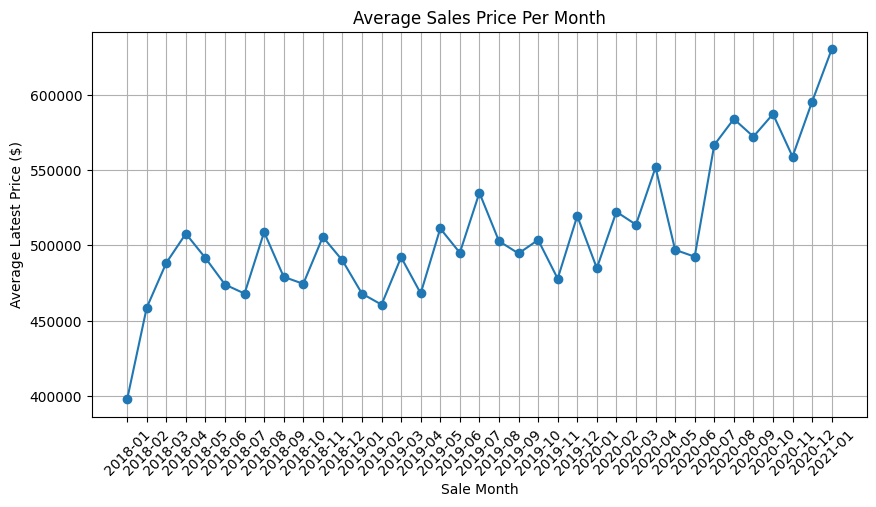

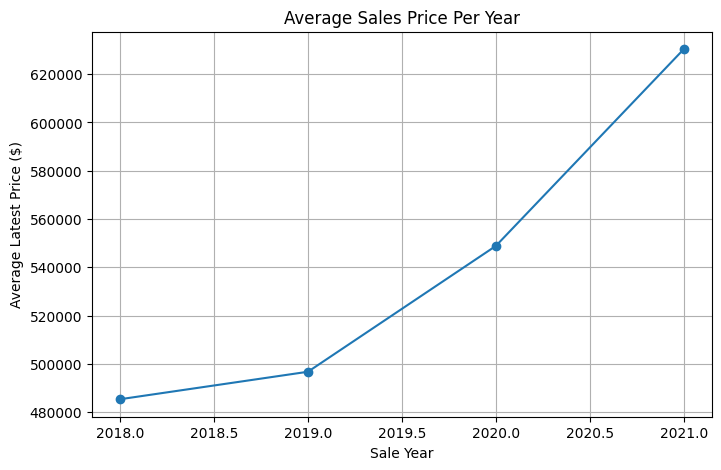

In [15]:
import matplotlib.pyplot as plt

df["latest_saledate"] = pd.to_datetime(df["latest_saledate"])


df["latest_salemonth"] = df["latest_saledate"].dt.to_period("M")
df["latest_saleyear"] = df["latest_saledate"].dt.year

df_monthly = df.groupby("latest_salemonth")["latestPrice"].mean()
plt.figure(figsize=(10, 5))
plt.plot(df_monthly.index.astype(str), df_monthly.values, marker='o', linestyle='-')
plt.xlabel("Sale Month")
plt.ylabel("Average Latest Price ($)")
plt.title("Average Sales Price Per Month")
plt.xticks(rotation=45)
plt.grid()
plt.show()

df_yearly = df.groupby("latest_saleyear")["latestPrice"].mean()
plt.figure(figsize=(8, 5))
plt.plot(df_yearly.index, df_yearly.values, marker='o', linestyle='-')
plt.xlabel("Sale Year")
plt.ylabel("Average Latest Price ($)")
plt.title("Average Sales Price Per Year")
plt.grid()
plt.show()

The data is great and seems very usable! Especially the trends over time portion. I think some of the columns may be unnecessary but overall I think there is a lot I can do with it.

There are some outliers. Tis is to be expected in real estate though. There are houses with 14 bathrooms out there.

Interestingly, the highest correlation on this list is between bathroom count and price at over .5. This makes sense though as higher-end home buyers expect more bathrooms. Often homes in the highest value bracket contain an en-suite bathroom in every bedroom.

There are some notable trends like watching the average sale price increase over time.

There are almost certainly confounding variables as real estate buyers want to have many things in mind when purchasing. For instance, proximity to the University of Texas is almost certainly a driver of value and yet it is only partially accounted for in zip code.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 86-98 of the Storytelling With Data book as best you can.  (The second half of chapter three).  You do not have to get the exact data values right, just the overall look and feel.

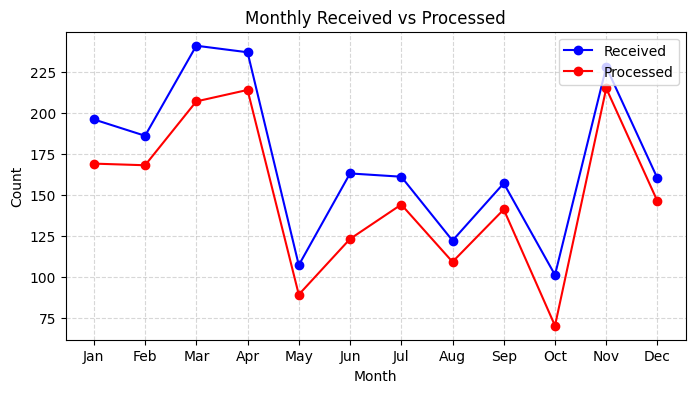

In [17]:
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
received = np.random.randint(100, 300, size=12)
processed = received - np.random.randint(10, 50, size=12)

plt.figure(figsize=(8, 4))
plt.plot(months, received, marker='o', linestyle='-', color='blue', label="Received")
plt.plot(months, processed, marker='o', linestyle='-', color='red', label="Processed")


plt.xlabel("Month")
plt.ylabel("Count")
plt.title("Monthly Received vs Processed")


plt.legend(loc="upper right")


plt.grid(True, linestyle="--", alpha=0.5)


plt.show()